# Logistic Regression

c:\Users\Luke Liu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.49421965317919075

Confusion Matrix:
[[112   2  12  30   3  15  17]
 [  9 101  15  17  12  37   3]
 [ 11  13  94  31  11  12  35]
 [ 25   5  30 107  21  17  28]
 [ 10  22  24  31  43   8   8]
 [ 13  50  16  27   4  70   5]
 [ 23   0  19  21   6   2 157]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.59      0.57       191
           1       0.52      0.52      0.52       194
           2       0.45      0.45      0.45       207
           3       0.41      0.46      0.43       233
           4       0.43      0.29      0.35       146
           5       0.43      0.38      0.40       185
           6       0.62      0.69      0.65       228

    accuracy                           0.49      1384
   macro avg       0.49      0.48      0.48      1384
weighted avg       0.49      0.49      0.49      1384



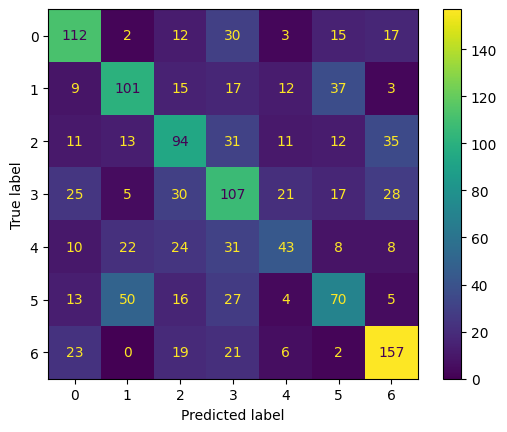

In [1]:
# logistic regression model here
# test out diff hyperparameters, ex. penalty type (L1/L2), regularization
# strength etc. 
# L2 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd 
import matplotlib.pyplot as plt
import pandas as pd 

X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
Y_train = pd.read_csv('../data/Y_train.csv') 
Y_test = pd.read_csv('../data/Y_test.csv')

y_train = Y_train.values.ravel()
y_test = Y_test.values.ravel()

model1 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(model1, X_test, y_test)
plt.show()




In [ ]:
# L1
model = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='saga',
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
# Testing c values 
c_values = [0.1, 0.3, 1, 10, 100] # 1/lambda
accuracies = []

for c in c_values:
    model = LogisticRegression(
        C=c,
        solver='lbfgs',
        max_iter=1000
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, y_pred)
    )
plt.plot(c_values, accuracies)
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Regularization")
plt.show()

In [ ]:
c_values = [0.1, 0.3, 1, 10, 100] # 1/lambda
accuracies = []
for c in c_values:
    model = LogisticRegression(
    penalty='l1',
    C=c,
    solver='saga',
    max_iter=1000
)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, y_pred)
    )
plt.plot(c_values, accuracies)
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Regularization")
plt.show()